# Plot1 - CarbonSavings vs. MakeSpan

## Line plot and Box plot

In [17]:
import pandas as pd
import glob
import os
location = "AU-SA"
# location = "California"
#############
# folder_type = "Homogen"
# folder_type = "Heterogen"
folder_type = "Heterogen_Energy"
############
mixed_objective = True # for energy-aware optimization that had a tie braker of carbon term
variable_timers = True
DAG = True
############
# root_dir = f"../Logs/GeneralExp"
root_dir = f"../Logs/GeneralExpv2/{folder_type}/{location}"
if variable_timers:
    root_dir = f"../Logs/GeneralExpv3-VariableTimer/{folder_type}/{location}"
if DAG:
    root_dir = f"../Logs/GeneralExpv2-DAG/{folder_type}/{location}"
if DAG and variable_timers:
    root_dir = f"../Logs/GeneralExpv3-DAG-VariableTimer/{folder_type}/{location}"
num_jobs = 10
num_servers = 5
num_operations = 4
#############

# Define the pattern
pattern = f"{num_jobs}J_{num_servers}S_{num_operations}O_MeanOp=7_v*.csv"
if mixed_objective:
    pattern = f"{num_jobs}J_{num_servers}S_{num_operations}O_MeanOp=7_MixedObjective_v*.csv"

# Get list of matching files
csv_files = glob.glob(f"{root_dir}/{pattern}")

# Read and concatenate all files
df_union = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_union.shape}")

✅ Loaded and merged 8 files. Final shape: (4311, 23)


In [18]:
df_logs = df_union[["Instance", "IsCarbonAware", "MaxMakeSpan", "MinMakeSpan", "SlackCoeff", "Makespan", "CarbonConsumption(g)", "EnergyConsumption(kWh)"]]

In [19]:
df_logs.head(12)

,Instance,IsCarbonAware,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),EnergyConsumption(kWh)
0,0,False,672,105,1.0,105,32229.00,255.75
1,0,True,105,105,1.0,105,26052.25,233.00
2,0,True,158,105,1.5,154,25087.50,224.75
3,0,True,210,105,2.0,210,24233.75,219.75
4,1,False,672,102,1.0,102,37474.50,298.50
5,1,True,102,102,1.0,102,35915.25,286.25
6,1,True,153,102,1.5,153,27345.50,280.00
7,1,True,204,102,2.0,204,33930.75,271.25
8,2,False,672,104,1.0,104,36734.75,300.50
9,2,True,104,104,1.0,104,35137.00,291.75


Average of the optimal makespan

In [20]:
import numpy as np
baseline = df_logs[df_logs["IsCarbonAware"] == False][["Makespan"]]
np.average(baseline["Makespan"])
# np.std(baseline["Makespan"])

np.float64(103.59537037037038)

In [21]:

# First, get baseline carbon consumption per instance where IsCarbonAware is False
baseline = df_logs[df_logs["IsCarbonAware"] == False][["Instance", "CarbonConsumption(g)", "EnergyConsumption(kWh)"]]
baseline = baseline.rename(columns={"CarbonConsumption(g)": "BaselineCarbon", "EnergyConsumption(kWh)": "BaselineEnergy"})
# Merge it back to original df to align baseline carbon for each instance
df_logs = df_logs.merge(baseline, on="Instance", how="left")
# Calculate savings
df_logs["CarbonSavings(%)"] = ((df_logs["BaselineCarbon"] - df_logs["CarbonConsumption(g)"]) / df_logs["BaselineCarbon"]) * 100
df_logs["EnergySavings(%)"] = ((df_logs["BaselineEnergy"] - df_logs["EnergyConsumption(kWh)"]) / df_logs["BaselineEnergy"]) * 100
df_logs.drop(columns=["BaselineCarbon", "BaselineEnergy"], inplace=True)
# Optional: round to 2 decimal places
df_logs["CarbonSavings(%)"] = df_logs["CarbonSavings(%)"].round(2)
df_logs["EnergySavings(%)"] = df_logs["EnergySavings(%)"].round(2)


In [22]:
df_logs.head(12)

,Instance,IsCarbonAware,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),EnergyConsumption(kWh),CarbonSavings(%),EnergySavings(%)
0,0,False,672,105,1.0,105,32229.00,255.75,0.00,0.00
1,0,True,105,105,1.0,105,26052.25,233.00,19.17,8.90
2,0,True,158,105,1.5,154,25087.50,224.75,22.16,12.12
3,0,True,210,105,2.0,210,24233.75,219.75,24.81,14.08
4,1,False,672,102,1.0,102,37474.50,298.50,0.00,0.00
5,1,True,102,102,1.0,102,35915.25,286.25,4.16,4.10
6,1,True,153,102,1.5,153,27345.50,280.00,27.03,6.20
7,1,True,204,102,2.0,204,33930.75,271.25,9.46,9.13
8,2,False,672,104,1.0,104,36734.75,300.50,0.00,0.00
9,2,True,104,104,1.0,104,35137.00,291.75,4.35,2.91


In [23]:
import ast
df_utilization = df_union [["Instance", "IsCarbonAware", "SlackCoeff", "MaxMakeSpan", "MinMakeSpan", "Makespan"] + [f"Server{i}" for i in range(num_servers)]]
df_utilization = df_utilization[df_utilization["IsCarbonAware"] == True]
server_columns = [col for col in df_utilization.columns if col.startswith('Server')]
for col in server_columns:
    df_utilization[col] = df_utilization[col].apply(ast.literal_eval)

In [24]:
slack_coeffs = list(df_utilization["SlackCoeff"].unique())
util_ratios = {} # per instance
util_final_ratio = {} # average over all instances
for slack_coeff in slack_coeffs:
    df = df_utilization[df_utilization["SlackCoeff"] == slack_coeff]
    util_ratios[slack_coeff] = [] # per instance
    for index, row in df.iterrows(): # per instance
        servers_utilization = {}
        for serverID in range(num_servers):
            server_status = row[f"Server{serverID}"]
            server_util = 0
            for [job_id, operation_id, start, end] in server_status:
                server_util += (end - start)
            servers_utilization[serverID] = server_util
        util_ratios[slack_coeff].append(np.sum(list(servers_utilization.values())) / (num_servers * row["MaxMakeSpan"]))
    util_final_ratio[slack_coeff] = round(np.average(util_ratios[slack_coeff]) * 100, 2)
# Convert keys and values to regular Python float
util_final_ratio = {float(k): float(v) for k, v in util_final_ratio.items()}
        

In [25]:
util_final_ratio

{1.0: 56.61, 1.5: 47.41, 2.0: 42.12}

In [26]:
import pandas as pd

# Filter only carbon-aware rows
df_filtered = df_logs[df_logs["IsCarbonAware"] == True].copy()
df_carbon_savings = df_filtered.groupby("SlackCoeff")["CarbonSavings(%)"].mean().reset_index()
df_energy_savings = df_filtered.groupby("SlackCoeff")["EnergySavings(%)"].mean().reset_index()
df_plot = pd.merge(df_carbon_savings, df_energy_savings, on="SlackCoeff")
df_plot['UtilizationRatio'] = df_plot['SlackCoeff'].map(util_final_ratio)

In [27]:
baseline = df_logs[df_logs["IsCarbonAware"] == False][["Makespan"]].copy()
avg_opt_makespan = round(float(np.average(baseline["Makespan"])), 2)
df_plot["AvgOptMakeSpan"] = avg_opt_makespan


In [28]:
df_plot

,SlackCoeff,CarbonSavings(%),EnergySavings(%),UtilizationRatio,AvgOptMakeSpan
0,1.0,11.643884,3.532736,56.61,103.6
1,1.5,27.186907,7.716444,47.41,103.6
2,2.0,32.709843,10.271750,42.12,103.6


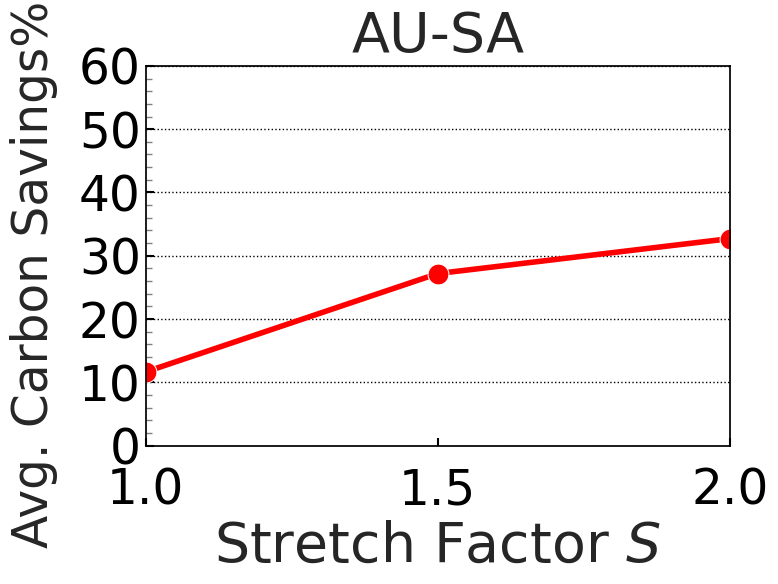

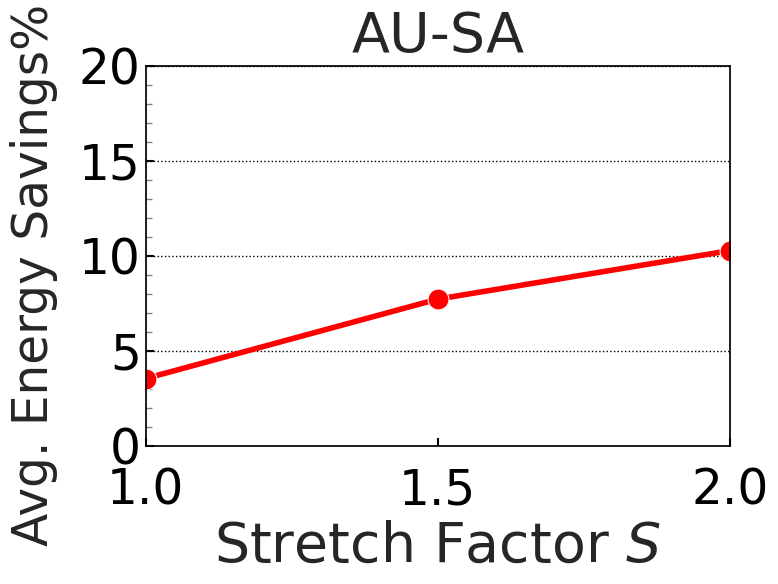

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import pandas as pd

###########
if location == "California":
    plot_title = "CAISO"
elif location == "AU-SA":
    plot_title = "AU-SA"
###########
save_fig = True
utilization_annotation = False
root_dir = f"./GeneralExpv2/{folder_type}/{location}"
if variable_timers:
    root_dir = f"./GeneralExpv3-VariableTime/{folder_type}/{location}"
if DAG:
    root_dir = f"./GeneralExpv2-DAG/{folder_type}/{location}"
if DAG and variable_timers:
    root_dir = f"./GeneralExpv3-DAG-VariableTime/{folder_type}/{location}"
########
save_data = True
if save_data:
    save_path = f"{root_dir}/{num_jobs}J_{num_servers}S_{num_operations}O_LinePlot_{plot_title}.csv"
    # if mixed_objective:
    #     save_file_path = f"{root_dir}/{num_jobs}J_{num_servers}S_{num_operations}O_WithTieBreaker_LinePlot_{plot_title}.csv"
    directory = os.path.dirname(save_path)
    os.makedirs(directory, exist_ok=True)
    df_plot.to_csv(save_path, index = False)
###########
plot_types = ["Carbon Savings", "Energy Savings"]
column_names = ["CarbonSavings(%)", "EnergySavings(%)"]
for plot_index, plot_type in enumerate(plot_types):
    save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_LinePlot_{plot_title}.png"
    if mixed_objective:
        save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_WithTieBreaker_LinePlot_{plot_title}.png"
    directory = os.path.dirname(save_file_path)
    os.makedirs(directory, exist_ok=True)

    # Seaborn & matplotlib styling
    # sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    sns.set(style="ticks", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    # Reset rcParams that might affect ticks
    plt.rcParams['ytick.minor.visible'] = True
    # Ensure 'x_label' is treated as string (categorical)
    df_plot["SlackCoeff"] = df_plot["SlackCoeff"].astype(str)
    
    line_color = "blue"
    if folder_type in ["Heterogen_Energy"]:
        line_color = "red"

    plt.figure(figsize=(8, 6))
    ax = sns.lineplot(
        data=df_plot,
        x="SlackCoeff",
        y=column_names[plot_index],
        marker="o",
        markersize=15,
        linewidth=4,
        color=line_color
    )

    # Labels
    # ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
    ax.set_xlabel(r"Stretch Factor $S$", fontsize=40)
    
    ax.set_ylabel(f"Avg. {plot_type}%", fontsize=35)
    ax.yaxis.set_label_coords(-0.15, 0.45)  # Move it 5% lower on the y-axis

    # Axis limits and tick font sizes
    if plot_type == "Carbon Savings":
        ax.set_ylim(0, 60)
        ax.set_yticks(range(0, 61, 10))
    else:
        ax.set_ylim(0, 20)
        ax.set_yticks(range(-0, 21, 5))
    ax.set_xlim(0, max(list(df_plot["SlackCoeff"])))
    ax.tick_params(axis='x', labelsize=35, color='black', pad=15)
    ax.tick_params(axis='y', labelsize=35, color='black')
    
    # Minor ticks
    ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')
    # Make major ticks point inward too
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.5)
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    # Ensure minor ticks are visible
    plt.minorticks_on()

    # Grid settings
    ax.grid(axis='x', visible=False)  # No x-grid
    ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
    # ax.grid(axis='y', which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.7)

    # Black border and ticks
    ax.tick_params(axis='both', color='black', labelcolor='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        
    ax.set_title(f"{plot_title}", fontsize=40, pad=10)

    # Annotate each point with UtilizationRatio
    if utilization_annotation:
        if plot_type == "Carbon Savings":
            for index, row in df_plot.iterrows():
                utilization_ratio = row['UtilizationRatio']
                x_pos = row['SlackCoeff']
                y_pos = row[column_names[plot_index]]
                
                # If it's the first point, adjust it slightly to the right
                if index == 0:
                    ax.text(float(x_pos) - 0.9, y_pos + 3, f"{utilization_ratio:.2f}%", 
                            color='black', fontsize=12, ha='center', va='bottom')
                else:
                    ax.text(x_pos, y_pos + 1.5, f"{utilization_ratio:.2f}%", 
                            color='black', fontsize=12, ha='center', va='bottom')

    plt.tight_layout()
    if save_fig:
        plt.savefig(save_file_path, dpi=300, bbox_inches='tight')
        pdf_save_path = save_file_path.replace(".png", ".pdf")
        plt.savefig(pdf_save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

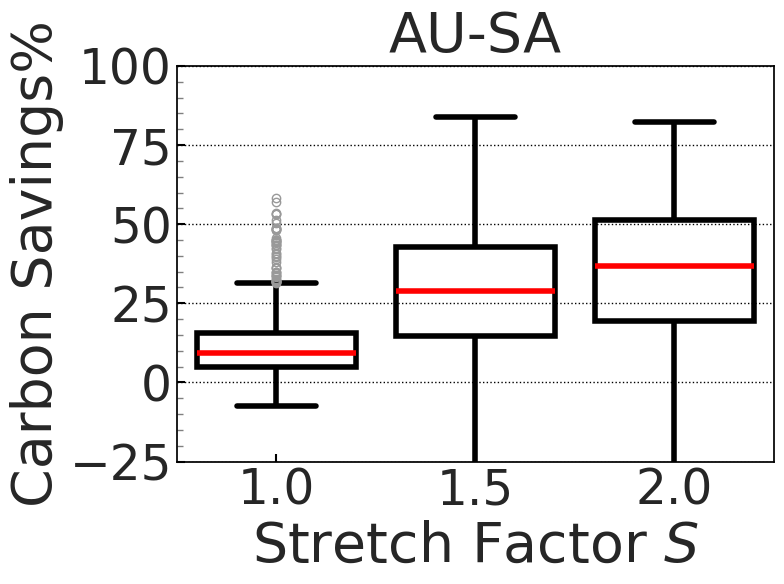

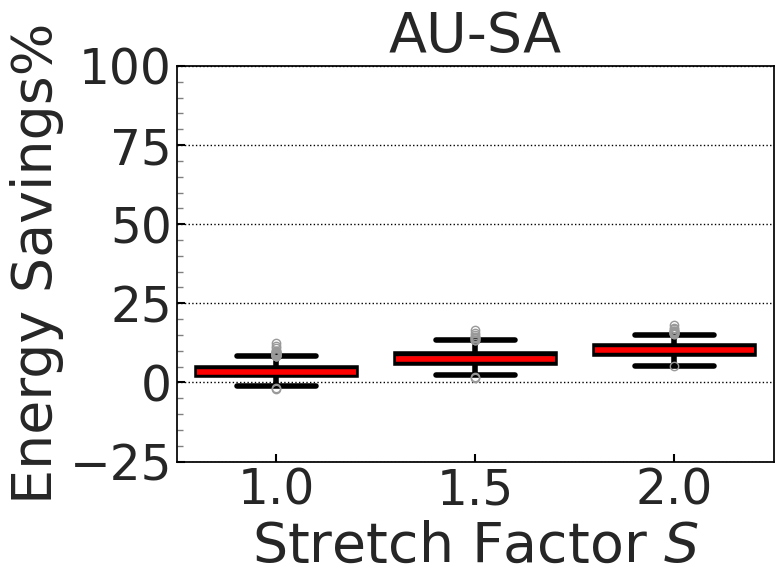

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import pandas as pd
###########
transparent_boxplot = True  # Set to False for normal colored plots
save_fig = True
save_data = True
###########
if location == "California":
    plot_title = "CAISO"
elif location == "AU-SA":
    plot_title = "AU-SA"
###########
utilization_annotation = False
root_dir = f"./GeneralExpv2/{folder_type}/{location}"
if variable_timers:
    root_dir = f"./GeneralExpv3-VariableTime//{folder_type}/{location}"
if DAG:
    root_dir = f"./GeneralExpv2-DAG/{folder_type}/{location}"
if DAG and variable_timers:
    root_dir = f"./GeneralExpv3-DAG-VariableTime/{folder_type}/{location}"
########
df_box = df_logs[df_logs["IsCarbonAware"] == True].copy()
if save_data:
    save_path = f"{root_dir}/{num_jobs}J_{num_servers}S_{num_operations}O_BoxPlot_{plot_title}.csv"
    directory = os.path.dirname(save_path)
    os.makedirs(directory, exist_ok=True)
    df_box.to_csv(save_path, index = False)
########
plot_types = ["Carbon Savings", "Energy Savings"]
column_names = ["CarbonSavings(%)", "EnergySavings(%)"]
for plot_index, plot_type in enumerate(plot_types):
    save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_BoxPlot_{plot_title}.png"
    if mixed_objective:
        save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_WithTieBreaker_BoxPlot_{plot_title}.png"
    directory = os.path.dirname(save_file_path)
    os.makedirs(directory, exist_ok=True)
    
    # Seaborn & matplotlib styling
    sns.set(style="ticks", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    plt.rcParams['ytick.minor.visible'] = True
    
    # Filter for carbon-aware runs only
    unique_labels = sorted(df_box["SlackCoeff"].unique())
    all_colors = ["lightseagreen", "khaki", "plum", "lightsalmon", "skyblue", "wheat", "orchid", "mistyrose", "lightcoral"]
    if folder_type in ["Heterogen", "Heterogen_Energy"]:
        inner_colors = ["lightseagreen", "khaki", "plum", "orchid"]
    elif folder_type in ["Homogen", "Homogen_Energy"]:
        inner_colors = ["lightcoral", "skyblue", "mistyrose", "orchid"]
    palette = inner_colors[:len(unique_labels)]
    df_box["SlackCoeff"] = df_box["SlackCoeff"].astype(str)
    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    box = sns.boxplot(
        data=df_box,
        x="SlackCoeff",
        y=column_names[plot_index],
        hue="SlackCoeff",
        # palette=palette,
        palette=palette if not transparent_boxplot else ["white"] * len(unique_labels),
        dodge=False,
        legend=False,
        ax = ax
    )
    
    
    # Forcefully update the patches
    for patch in ax.patches:
        patch.set_linewidth(4)
        patch.set_edgecolor("black")
        if transparent_boxplot:
            patch.set_facecolor('none')  # make it transparent

    # Manually adjust all the lines for whiskers, caps, and medians
    for i, line in enumerate(ax.lines):
        line.set_linewidth(4)
        # line.set_color("black")
        if transparent_boxplot:
            # Each box has: 1 median, 2 whiskers, 2 caps → median every 6th line starting from index 4
            if (i - 4) % 6 == 0:
                line.set_color("red")
            else:
                line.set_color("black")
        else:
            line.set_color("black")
    
    # Axis labels
    ax.set_xlabel(r"Stretch Factor $S$", fontsize=40)
    ax.set_ylabel(f"{plot_type}%", fontsize=40)

    # Axis ticks and limits
    ax.set_ylim(-25, 100)
    ax.set_yticks(range(-25, 101, 25))
    # ax.set_xlim(0, max(list(df_plot["SlackCoeff"])))
    ax.tick_params(axis='x', labelsize=35, color='black')
    ax.tick_params(axis='y', labelsize=35, color='black')

    # Minor ticks
    ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')
    # Make major ticks point inward too
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.5)
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    # Ensure minor ticks are visible
    plt.minorticks_on()

    # Grid & borders
    ax.grid(axis='x', visible=False)
    ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
    ax.set_title(f"{plot_title}", fontsize=40, pad=10)
    plt.tight_layout()
    if save_fig:
        plt.savefig(save_file_path, dpi=300, bbox_inches='tight')
        pdf_save_path = save_file_path.replace(".png", ".pdf")
        plt.savefig(pdf_save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

Caclulating p-value to see if the results are statistically significant or not

In [24]:
from scipy.stats import mannwhitneyu
import itertools
import pandas as pd

# Ensure SlackCoeff is treated numerically for correct sorting
df_box["SlackCoeff"] = df_box["SlackCoeff"].astype(float)

# Get all unique values of SlackCoeff
unique_slack_coeffs = sorted(df_box["SlackCoeff"].unique())

# Store p-values
pval_results = []

# Compute Mann–Whitney U test for each pair of SlackCoeff groups
for sc1, sc2 in itertools.combinations(unique_slack_coeffs, 2):
    data1 = df_box[df_box["SlackCoeff"] == sc1]["CarbonSavings(%)"]
    data2 = df_box[df_box["SlackCoeff"] == sc2]["CarbonSavings(%)"]
    
    stat, p = mannwhitneyu(data1, data2, alternative='two-sided')
    pval_results.append({
        "SlackCoeff 1": sc1,
        "SlackCoeff 2": sc2,
        "p-value": p
    })

# Convert to DataFrame for inspection
pval_df = pd.DataFrame(pval_results)
print(pval_df)

   SlackCoeff 1  SlackCoeff 2       p-value
0           1.0           1.5  2.694690e-01
1           1.0           2.0  4.307939e-18
2           1.5           2.0  6.622275e-22


## Plot 1.1. Carbon vs. Energy Trade-off

In [52]:
import pandas as pd
location == "AU-SA"
num_jobs = 10
num_servers = 5
num_operations = 4

folder1_type = "Heterogen"
folder2_type = "Heterogen_Energy"
folder_type = "CarbonVsEnergy"

DAG = True
variable_timers = True

df_plot1 = pd.read_csv(f"/nfs/obelix/users1/rbostandoost/HotCarbon25/Plot/GeneralExpv3-DAG-VariableTime/{folder1_type}/{location}/{num_jobs}J_{num_servers}S_{num_operations}O_LinePlot_AU-SA.csv")
df_plot2 = pd.read_csv(f"/nfs/obelix/users1/rbostandoost/HotCarbon25/Plot/GeneralExpv3-DAG-VariableTime/{folder2_type}/{location}/{num_jobs}J_{num_servers}S_{num_operations}O_LinePlot_AU-SA.csv")

key_col = "SlackCoeff"
df1_prefixed = df_plot1.set_index(key_col).add_prefix("Carbon_")
df2_prefixed = df_plot2.set_index(key_col).add_prefix("Energy_")
df_unified = pd.concat([df1_prefixed, df2_prefixed], axis=1).reset_index()

In [53]:
df_unified

,SlackCoeff,Carbon_CarbonSavings(%),Carbon_EnergySavings(%),Carbon_UtilizationRatio,Carbon_AvgOptMakeSpan,Energy_CarbonSavings(%),Energy_EnergySavings(%),Energy_UtilizationRatio,Energy_AvgOptMakeSpan
0,1.0,18.447882,1.828759,55.02,103.6,11.643884,3.532736,56.61,103.6
1,1.5,43.688741,3.085093,40.96,103.6,27.186907,7.716444,47.41,103.6
2,2.0,52.286315,3.276657,31.10,103.6,32.709843,10.271750,42.12,103.6


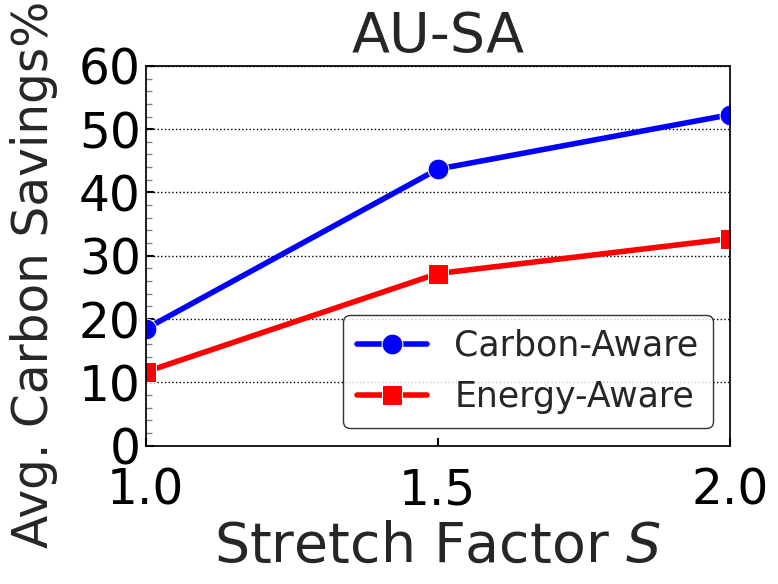

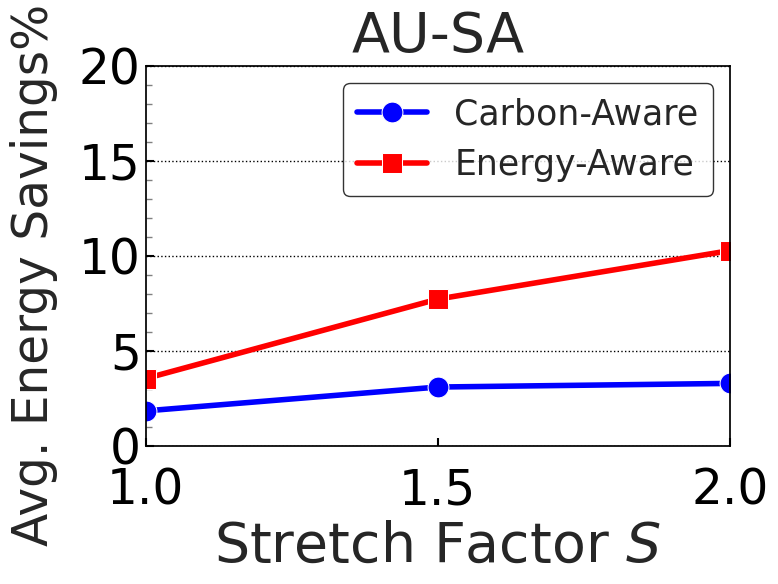

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import pandas as pd

###########
if location == "California":
    plot_title = "CAISO"
elif location == "AU-SA":
    plot_title = "AU-SA"
###########
save_fig = True
utilization_annotation = False
root_dir = f"./GeneralExpv2/{folder_type}/{location}"
if variable_timers:
    root_dir = f"./GeneralExpv3-VariableTime/{folder_type}/{location}"
if DAG:
    root_dir = f"./GeneralExpv2-DAG/{folder_type}/{location}"
if DAG and variable_timers:
    root_dir = f"./GeneralExpv3-DAG-VariableTime/{folder_type}/{location}"
########
save_data = True
if save_data:
    save_path = f"{root_dir}/{num_jobs}J_{num_servers}S_{num_operations}O_LinePlot_{plot_title}.csv"
    directory = os.path.dirname(save_path)
    os.makedirs(directory, exist_ok=True)
    df_unified.to_csv(save_path, index = False)
###########
plot_types = ["Carbon Savings", "Energy Savings"]
column_names = ["CarbonSavings(%)", "EnergySavings(%)"]
for plot_index, plot_type in enumerate(plot_types):
    save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_LinePlot_{plot_title}.png"
    if mixed_objective:
        save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_WithTieBreaker_LinePlot_{plot_title}.png"
    directory = os.path.dirname(save_file_path)
    os.makedirs(directory, exist_ok=True)

    # Seaborn & matplotlib styling
    # sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    sns.set(style="ticks", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    # Reset rcParams that might affect ticks
    plt.rcParams['ytick.minor.visible'] = True
    # Ensure 'x_label' is treated as string (categorical)
    df_plot1["SlackCoeff"] = df_plot1["SlackCoeff"].astype(str)
    df_plot2["SlackCoeff"] = df_plot2["SlackCoeff"].astype(str)
    
    # line_color = "blue"
    # if folder_type in ["Heterogen_Energy"]:
    #     line_color = "red"
    plt.figure(figsize=(8, 6))
    ax = sns.lineplot(
        data=df_plot1,
        x="SlackCoeff",
        y=column_names[plot_index],
        marker="o",
        markersize=15,
        linewidth=4,
        color="blue",
        label="Carbon-Aware"
    )

    sns.lineplot(
        data=df_plot2,
        x="SlackCoeff",
        y=column_names[plot_index],
        marker="s",
        markersize=15,
        linewidth=4,
        color="red",
        label="Energy-Aware"
    )

    # Labels
    # ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
    ax.set_xlabel(r"Stretch Factor $S$", fontsize=40)
    
    ax.set_ylabel(f"Avg. {plot_type}%", fontsize=35)
    ax.yaxis.set_label_coords(-0.15, 0.45)  # Move it 5% lower on the y-axis

    # Axis limits and tick font sizes
    if plot_type == "Carbon Savings":
        ax.set_ylim(0, 60)
        ax.set_yticks(range(0, 61, 10))
    else:
        ax.set_ylim(0, 20)
        ax.set_yticks(range(-0, 21, 5))
    ax.set_xlim(0, len(list(df_plot1["SlackCoeff"]))-1)
    ax.tick_params(axis='x', labelsize=35, color='black', pad=15)
    ax.tick_params(axis='y', labelsize=35, color='black')
    
    # Minor ticks
    ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')
    # Make major ticks point inward too
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.5)
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    # Ensure minor ticks are visible
    plt.minorticks_on()

    # Grid settings
    ax.grid(axis='x', visible=False)  # No x-grid
    ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
    # ax.grid(axis='y', which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.7)

    # Black border and ticks
    ax.tick_params(axis='both', color='black', labelcolor='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        
    ax.set_title(f"{plot_title}", fontsize=40, pad=10)
    ax.legend(fontsize=25, loc='best', frameon=True, edgecolor='black')

    plt.tight_layout()
    if save_fig:
        plt.savefig(save_file_path, dpi=300, bbox_inches='tight')
        pdf_save_path = save_file_path.replace(".png", ".pdf")
        plt.savefig(pdf_save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

# Plot2 - Effect of Number of Servers

In [32]:
import pandas as pd
import glob
import os
# location = "AU-SA"
location = "California"
#############
folder_type = "Homogen"
# folder_type = "Heterogen"
# folder_type = "Heterogen_Energy"
############
# root_dir = f"../Logs/GeneralExp"
root_dir = f"../Logs/GeneralExpv2/{folder_type}/{location}"
num_jobs = 10
list_num_servers = [5, 10, 15]
num_operations = 3
list_dfs = []
for num_servers in list_num_servers:
    # reading the df for a specific number of servers
    pattern = f"{num_jobs}J_{num_servers}S_{num_operations}O_MeanOp=7_v*.csv"
    csv_files = glob.glob(f"{root_dir}/{pattern}")
    df_logs = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
    df_logs = df_logs[df_logs["SlackCoeff"] == 1]
    # Calculating the carbon and energy savings
    # First, get baseline carbon consumption per instance where IsCarbonAware is False
    baseline = df_logs[df_logs["IsCarbonAware"] == False][["Instance", "CarbonConsumption(g)", "EnergyConsumption(kWh)"]]
    baseline = baseline.rename(columns={"CarbonConsumption(g)": "BaselineCarbon", "EnergyConsumption(kWh)": "BaselineEnergy"})
    # Merge it back to original df to align baseline carbon for each instance
    df_logs = df_logs.merge(baseline, on="Instance", how="left")
    # Calculate savings
    df_logs["CarbonSavings(%)"] = ((df_logs["BaselineCarbon"] - df_logs["CarbonConsumption(g)"]) / df_logs["BaselineCarbon"]) * 100
    df_logs["EnergySavings(%)"] = ((df_logs["BaselineEnergy"] - df_logs["EnergyConsumption(kWh)"]) / df_logs["BaselineEnergy"]) * 100
    df_logs.drop(columns=["BaselineCarbon", "BaselineEnergy"], inplace=True)
    # Optional: round to 2 decimal places
    df_logs["CarbonSavings(%)"] = df_logs["CarbonSavings(%)"].round(2)
    df_logs["EnergySavings(%)"] = df_logs["EnergySavings(%)"].round(2)
    # adding to list of dfs
    list_dfs.append(df_logs)
    print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_logs.shape}")
df_union = pd.concat(list_dfs, ignore_index=True)
df_logs = df_union[["Instance", "ServerNumber", "IsCarbonAware", "MaxMakeSpan", "MinMakeSpan", "SlackCoeff", "Makespan", "CarbonConsumption(g)", "EnergyConsumption(kWh)", "CarbonSavings(%)", "EnergySavings(%)"]]
# df_union = df_union[df_union["SlackCoeff"] == 1]

✅ Loaded and merged 8 files. Final shape: (2160, 25)
✅ Loaded and merged 8 files. Final shape: (2160, 30)
✅ Loaded and merged 8 files. Final shape: (2160, 35)


In [34]:
len(df_logs)

6480

In [35]:
df_logs

,Instance,ServerNumber,IsCarbonAware,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),EnergyConsumption(kWh),CarbonSavings(%),EnergySavings(%)
0,0,5,False,672,111,1.0,111,12887.25,37.50,0.00,0.0
1,0,5,True,111,111,1.0,111,7994.25,37.50,37.97,0.0
2,1,5,False,672,142,1.0,142,18906.25,58.00,0.00,0.0
3,1,5,True,142,142,1.0,142,14490.00,58.00,23.36,0.0
4,2,5,False,672,123,1.0,123,17032.75,60.50,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...
6475,1077,15,True,109,109,1.0,109,8970.00,57.25,29.66,0.0
6476,1078,15,False,672,87,1.0,87,8826.50,40.75,0.00,0.0
6477,1078,15,True,87,87,1.0,87,6088.50,40.75,31.02,0.0
6478,1079,15,False,672,95,1.0,95,10578.50,54.00,0.00,0.0


In [37]:
import pandas as pd

# Filter only carbon-aware rows
df_filtered = df_logs[df_logs["IsCarbonAware"] == True].copy()
df_carbon_savings = df_filtered.groupby("ServerNumber")["CarbonSavings(%)"].mean().reset_index()
df_energy_savings = df_filtered.groupby("ServerNumber")["EnergySavings(%)"].mean().reset_index()
df_plot = pd.merge(df_carbon_savings, df_energy_savings, on="ServerNumber")
# df_plot['UtilizationRatio'] = df_plot['SlackCoeff'].map(util_final_ratio)

In [38]:
df_plot

,ServerNumber,CarbonSavings(%),EnergySavings(%)
0,5,26.956583,0.0
1,10,30.566889,0.0
2,15,29.314083,0.0


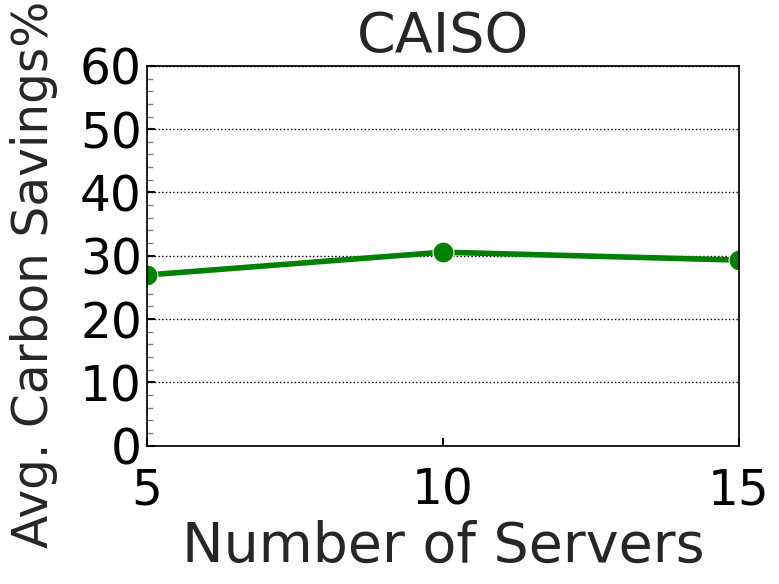

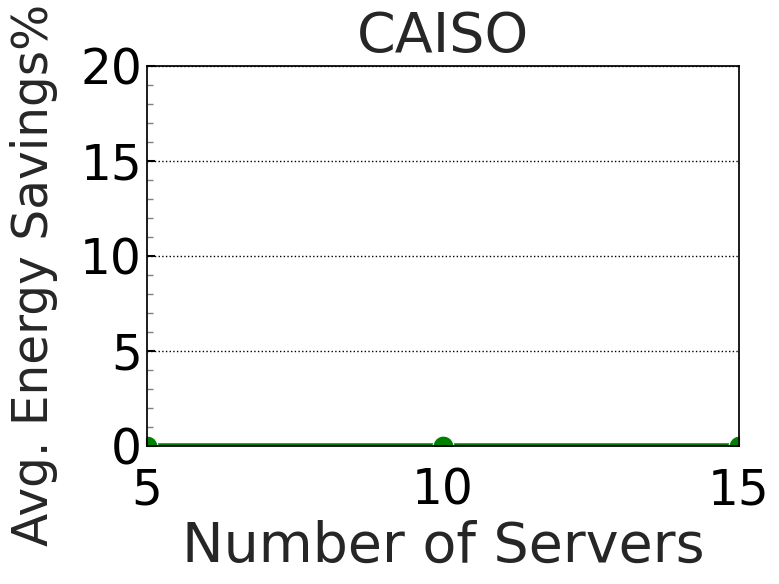

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import pandas as pd

###########
if location == "California":
    plot_title = "CAISO"
elif location == "AU-SA":
    plot_title = "AU-SA"
###########
save_fig = True
utilization_annotation = False
root_dir = f"./Effect of Parameters/Number of Servers/{folder_type}/{location}"
########
save_data = True
if save_data:
    save_path = f"{root_dir}/{num_jobs}J_{num_operations}O_LinePlot_{plot_title}.csv"
    # if mixed_objective:
    #     save_file_path = f"{root_dir}/{num_jobs}J_{num_servers}S_{num_operations}O_WithTieBreaker_LinePlot_{plot_title}.csv"
    directory = os.path.dirname(save_path)
    os.makedirs(directory, exist_ok=True)
    df_plot.to_csv(save_path, index = False)
###########
plot_types = ["Carbon Savings", "Energy Savings"]
column_names = ["CarbonSavings(%)", "EnergySavings(%)"]
for plot_index, plot_type in enumerate(plot_types):
    save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_operations}O_LinePlot_{plot_title}.png"
    directory = os.path.dirname(save_file_path)
    os.makedirs(directory, exist_ok=True)

    # Seaborn & matplotlib styling
    # sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    sns.set(style="ticks", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    # Reset rcParams that might affect ticks
    plt.rcParams['ytick.minor.visible'] = True
    # Ensure 'x_label' is treated as string (categorical)
    df_plot["ServerNumber"] = df_plot["ServerNumber"].astype(str)
    
    line_color = "green"
    if folder_type in ["Heterogen_Energy"]:
        line_color = "red"

    plt.figure(figsize=(8, 6))
    ax = sns.lineplot(
        data=df_plot,
        x="ServerNumber",
        y=column_names[plot_index],
        marker="o",
        markersize=15,
        linewidth=4,
        color=line_color
    )

    # Labels
    # ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
    ax.set_xlabel(r"Number of Servers", fontsize=40)
    
    ax.set_ylabel(f"Avg. {plot_type}%", fontsize=35)
    ax.yaxis.set_label_coords(-0.15, 0.45)  # Move it 5% lower on the y-axis

    # Axis limits and tick font sizes
    if plot_type == "Carbon Savings":
        ax.set_ylim(0, 60)
        ax.set_yticks(range(0, 61, 10))
    else:
        ax.set_ylim(0, 20)
        ax.set_yticks(range(-0, 21, 5))
    ax.set_xlim(0, len(list(df_plot["ServerNumber"]))-1)
    ax.tick_params(axis='x', labelsize=35, color='black', pad=15)
    ax.tick_params(axis='y', labelsize=35, color='black')
    
    # Minor ticks
    ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')
    # Make major ticks point inward too
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.5)
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    # Ensure minor ticks are visible
    plt.minorticks_on()

    # Grid settings
    ax.grid(axis='x', visible=False)  # No x-grid
    ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
    # ax.grid(axis='y', which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.7)

    # Black border and ticks
    ax.tick_params(axis='both', color='black', labelcolor='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        
    ax.set_title(f"{plot_title}", fontsize=40, pad=10)

    # Annotate each point with UtilizationRatio
    if utilization_annotation:
        if plot_type == "Carbon Savings":
            for index, row in df_plot.iterrows():
                utilization_ratio = row['UtilizationRatio']
                x_pos = row['ServerNumber']
                y_pos = row[column_names[plot_index]]
                
                # If it's the first point, adjust it slightly to the right
                if index == 0:
                    ax.text(float(x_pos) - 0.9, y_pos + 3, f"{utilization_ratio:.2f}%", 
                            color='black', fontsize=12, ha='center', va='bottom')
                else:
                    ax.text(x_pos, y_pos + 1.5, f"{utilization_ratio:.2f}%", 
                            color='black', fontsize=12, ha='center', va='bottom')

    plt.tight_layout()
    if save_fig:
        plt.savefig(save_file_path, dpi=300, bbox_inches='tight')
        pdf_save_path = save_file_path.replace(".png", ".pdf")
        plt.savefig(pdf_save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

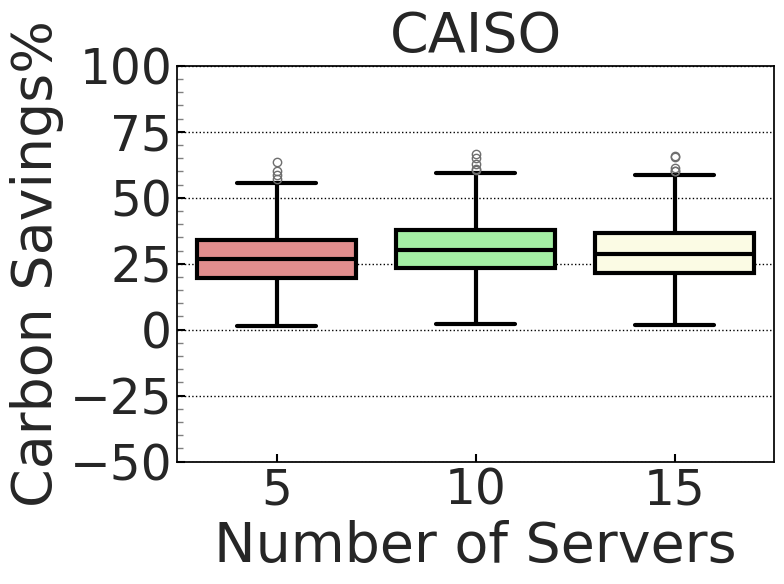

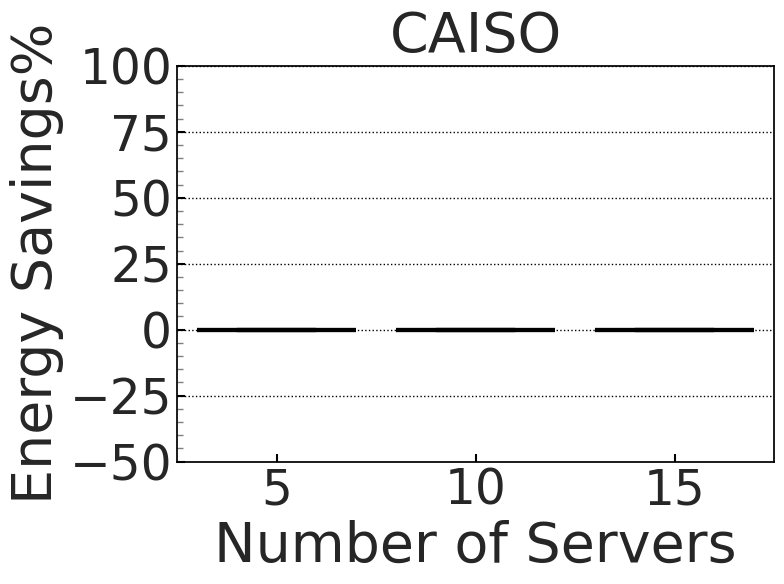

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import pandas as pd
###########
if location == "California":
    plot_title = "CAISO"
elif location == "AU-SA":
    plot_title = "AU-SA"
###########
save_fig = True
utilization_annotation = False
root_dir = f"./Effect of Parameters/Number of Servers/{folder_type}/{location}"
########
df_box = df_logs[df_logs["IsCarbonAware"] == True].copy()
save_data = False
if save_data:
    save_path = f"{root_dir}/{num_jobs}J_{num_operations}O_BoxPlot_{plot_title}.csv"
    directory = os.path.dirname(save_path)
    os.makedirs(directory, exist_ok=True)
    df_plot.to_csv(save_path, index = False)
########
plot_types = ["Carbon Savings", "Energy Savings"]
column_names = ["CarbonSavings(%)", "EnergySavings(%)"]
for plot_index, plot_type in enumerate(plot_types):
    save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_operations}O_BoxPlot_{plot_title}.png"
    # if mixed_objective:
    #     save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_WithTieBreaker_BoxPlot_{plot_title}.png"
    directory = os.path.dirname(save_file_path)
    os.makedirs(directory, exist_ok=True)
    
    # Seaborn & matplotlib styling
    sns.set(style="ticks", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    plt.rcParams['ytick.minor.visible'] = True
    
    # Filter for carbon-aware runs only
    unique_labels = sorted(df_box["ServerNumber"].unique())
    all_colors = ["lightseagreen", "khaki", "plum", "lightsalmon", "skyblue", "wheat", "orchid", "mistyrose", "lightcoral"]
    if folder_type in ["Heterogen", "Heterogen_Energy"]:
        inner_colors = ["lightseagreen", "khaki", "plum"]
    elif folder_type in ["Homogen", "Homogen_Energy"]:
        # inner_colors = ["lightcoral", "skyblue", "mistyrose"]
        # inner_colors = ["lightcoral", "wheat", "orchid"]
        inner_colors = ["lightcoral", "palegreen", "lightyellow"]
    palette = inner_colors[:len(unique_labels)]
    df_box["ServerNumber"] = df_box["ServerNumber"].astype(str)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    box = sns.boxplot(
        data=df_box,
        x="ServerNumber",
        y=column_names[plot_index],
        hue="ServerNumber",
        palette=palette,
        dodge=False,
        legend=False,
        ax = ax
    )
    
    
    # Forcefully update the patches
    for patch in ax.patches:
        patch.set_linewidth(3)
        patch.set_edgecolor("black")

    # Manually adjust all the lines for whiskers, caps, and medians
    for line in ax.lines:
        line.set_linewidth(3)
        line.set_color("black")
    
    # Axis labels
    ax.set_xlabel(r"Number of Servers", fontsize=40)
    ax.set_ylabel(f"{plot_type}%", fontsize=40)

    # Axis ticks and limits
    ax.set_ylim(-50, 100)
    # ax.set_ylim(0, 100) #v2
    ax.set_yticks(range(-50, 101, 25))
    # ax.set_yticks(range(0, 101, 20)) #v2
    ax.tick_params(axis='x', labelsize=35, color='black')
    ax.tick_params(axis='y', labelsize=35, color='black')

    # Minor ticks
    ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')
    # Make major ticks point inward too
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.5)
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    # Ensure minor ticks are visible
    plt.minorticks_on()

    # Grid & borders
    ax.grid(axis='x', visible=False)
    ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
    ax.set_title(f"{plot_title}", fontsize=40, pad=10)
    plt.tight_layout()
    if save_fig:
        plt.savefig(save_file_path, dpi=300, bbox_inches='tight')
        pdf_save_path = save_file_path.replace(".png", ".pdf")
        plt.savefig(pdf_save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

# Plot3 - Effect of Number of Operations

In [63]:
import pandas as pd
import glob
import os
# location = "AU-SA"
location = "California"
#############
folder_type = "Homogen"
# folder_type = "Heterogen"
# folder_type = "Heterogen_Energy"
############
# root_dir = f"../Logs/GeneralExp"
root_dir = f"../Logs/GeneralExpv2/{folder_type}/{location}"
num_jobs = 10
num_servers = 5
num_operations = 3
list_num_operations = [2, 3, 5]
list_dfs = []
for num_operations in list_num_operations:
    # reading the df for a specific number of servers
    pattern = f"{num_jobs}J_{num_servers}S_{num_operations}O_MeanOp=7_v*.csv"
    csv_files = glob.glob(f"{root_dir}/{pattern}")
    df_logs = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
    df_logs = df_logs[df_logs["SlackCoeff"] == 1]
    # Calculating the carbon and energy savings
    # First, get baseline carbon consumption per instance where IsCarbonAware is False
    baseline = df_logs[df_logs["IsCarbonAware"] == False][["Instance", "CarbonConsumption(g)", "EnergyConsumption(kWh)"]]
    baseline = baseline.rename(columns={"CarbonConsumption(g)": "BaselineCarbon", "EnergyConsumption(kWh)": "BaselineEnergy"})
    # Merge it back to original df to align baseline carbon for each instance
    df_logs = df_logs.merge(baseline, on="Instance", how="left")
    # Calculate savings
    df_logs["CarbonSavings(%)"] = ((df_logs["BaselineCarbon"] - df_logs["CarbonConsumption(g)"]) / df_logs["BaselineCarbon"]) * 100
    df_logs["EnergySavings(%)"] = ((df_logs["BaselineEnergy"] - df_logs["EnergyConsumption(kWh)"]) / df_logs["BaselineEnergy"]) * 100
    df_logs.drop(columns=["BaselineCarbon", "BaselineEnergy"], inplace=True)
    # Optional: round to 2 decimal places
    df_logs["CarbonSavings(%)"] = df_logs["CarbonSavings(%)"].round(2)
    df_logs["EnergySavings(%)"] = df_logs["EnergySavings(%)"].round(2)
    # adding to list of dfs
    list_dfs.append(df_logs)
    print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_logs.shape}")
df_union = pd.concat(list_dfs, ignore_index=True)
df_logs = df_union[["Instance", "OperationsPerJob", "IsCarbonAware", "MaxMakeSpan", "MinMakeSpan", "SlackCoeff", "Makespan", "CarbonConsumption(g)", "EnergyConsumption(kWh)", "CarbonSavings(%)", "EnergySavings(%)"]]
# df_union = df_union[df_union["SlackCoeff"] == 1]

✅ Loaded and merged 8 files. Final shape: (2160, 25)
✅ Loaded and merged 8 files. Final shape: (2160, 25)
✅ Loaded and merged 8 files. Final shape: (2159, 25)


In [64]:
len(df_logs)

6479

In [67]:
df_logs

,Instance,OperationsPerJob,IsCarbonAware,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),EnergyConsumption(kWh),CarbonSavings(%),EnergySavings(%)
0,0,2,False,672,107,1.0,107,9743.25,31.25,0.00,0.0
1,0,2,True,107,107,1.0,107,6449.75,31.25,33.80,0.0
2,1,2,False,672,115,1.0,115,9528.75,30.00,0.00,0.0
3,1,2,True,115,115,1.0,115,6220.25,30.00,34.72,0.0
4,2,2,False,672,107,1.0,107,11193.00,39.75,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...
6474,1077,5,True,122,122,1.0,122,14587.00,77.25,11.76,0.0
6475,1078,5,False,672,105,1.0,105,18372.50,93.50,0.00,0.0
6476,1078,5,True,105,105,1.0,105,18237.00,93.50,0.74,0.0
6477,1079,5,False,672,122,1.0,122,20600.75,101.00,0.00,0.0


In [65]:
import pandas as pd

# Filter only carbon-aware rows
df_filtered = df_logs[df_logs["IsCarbonAware"] == True].copy()
df_carbon_savings = df_filtered.groupby("OperationsPerJob")["CarbonSavings(%)"].mean().reset_index()
df_energy_savings = df_filtered.groupby("OperationsPerJob")["EnergySavings(%)"].mean().reset_index()
df_plot = pd.merge(df_carbon_savings, df_energy_savings, on="OperationsPerJob")
# df_plot['UtilizationRatio'] = df_plot['SlackCoeff'].map(util_final_ratio)

In [66]:
df_plot

,OperationsPerJob,CarbonSavings(%),EnergySavings(%)
0,2,32.005685,0.0
1,3,26.956583,0.0
2,5,13.259518,0.0


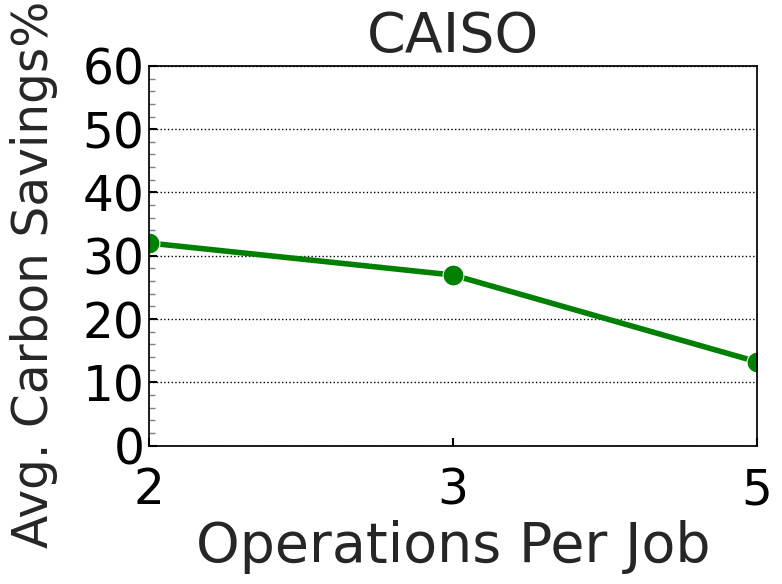

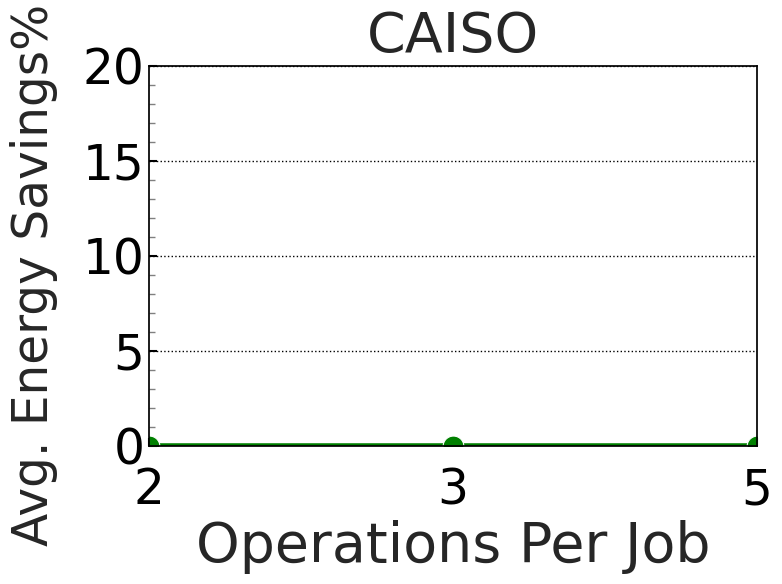

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import pandas as pd

###########
if location == "California":
    plot_title = "CAISO"
elif location == "AU-SA":
    plot_title = "AU-SA"
###########
save_fig = True
utilization_annotation = False
root_dir = f"./Effect of Parameters/Operations Per Job/{folder_type}/{location}"
########
save_data = True
if save_data:
    save_path = f"{root_dir}/{num_jobs}J_{num_servers}S_LinePlot_{plot_title}.csv"
    # if mixed_objective:
    #     save_file_path = f"{root_dir}/{num_jobs}J_{num_operations}O_WithTieBreaker_LinePlot_{plot_title}.csv"
    directory = os.path.dirname(save_path)
    os.makedirs(directory, exist_ok=True)
    df_plot.to_csv(save_path, index = False)
###########
plot_types = ["Carbon Savings", "Energy Savings"]
column_names = ["CarbonSavings(%)", "EnergySavings(%)"]
for plot_index, plot_type in enumerate(plot_types):
    save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_LinePlot_{plot_title}.png"
    directory = os.path.dirname(save_file_path)
    os.makedirs(directory, exist_ok=True)

    # Seaborn & matplotlib styling
    # sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    sns.set(style="ticks", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    # Reset rcParams that might affect ticks
    plt.rcParams['ytick.minor.visible'] = True
    # Ensure 'x_label' is treated as string (categorical)
    df_plot["OperationsPerJob"] = df_plot["OperationsPerJob"].astype(str)
    
    line_color = "green"
    if folder_type in ["Heterogen_Energy"]:
        line_color = "red"

    plt.figure(figsize=(8, 6))
    ax = sns.lineplot(
        data=df_plot,
        x="OperationsPerJob",
        y=column_names[plot_index],
        marker="o",
        markersize=15,
        linewidth=4,
        color=line_color
    )

    # Labels
    # ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
    ax.set_xlabel(r"Operations Per Job", fontsize=40)
    
    ax.set_ylabel(f"Avg. {plot_type}%", fontsize=35)
    ax.yaxis.set_label_coords(-0.15, 0.45)  # Move it 5% lower on the y-axis

    # Axis limits and tick font sizes
    if plot_type == "Carbon Savings":
        ax.set_ylim(0, 60)
        ax.set_yticks(range(0, 61, 10))
    else:
        ax.set_ylim(0, 20)
        ax.set_yticks(range(-0, 21, 5))
    ax.set_xlim(0, len(list(df_plot["OperationsPerJob"]))-1)
    ax.tick_params(axis='x', labelsize=35, color='black', pad=15)
    ax.tick_params(axis='y', labelsize=35, color='black')
    
    # Minor ticks
    ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')
    # Make major ticks point inward too
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.5)
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    # Ensure minor ticks are visible
    plt.minorticks_on()

    # Grid settings
    ax.grid(axis='x', visible=False)  # No x-grid
    ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
    # ax.grid(axis='y', which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.7)

    # Black border and ticks
    ax.tick_params(axis='both', color='black', labelcolor='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        
    ax.set_title(f"{plot_title}", fontsize=40, pad=10)

    # Annotate each point with UtilizationRatio
    if utilization_annotation:
        if plot_type == "Carbon Savings":
            for index, row in df_plot.iterrows():
                utilization_ratio = row['UtilizationRatio']
                x_pos = row['OperationsPerJob']
                y_pos = row[column_names[plot_index]]
                
                # If it's the first point, adjust it slightly to the right
                if index == 0:
                    ax.text(float(x_pos) - 0.9, y_pos + 3, f"{utilization_ratio:.2f}%", 
                            color='black', fontsize=12, ha='center', va='bottom')
                else:
                    ax.text(x_pos, y_pos + 1.5, f"{utilization_ratio:.2f}%", 
                            color='black', fontsize=12, ha='center', va='bottom')

    plt.tight_layout()
    if save_fig:
        plt.savefig(save_file_path, dpi=300, bbox_inches='tight')
        pdf_save_path = save_file_path.replace(".png", ".pdf")
        plt.savefig(pdf_save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

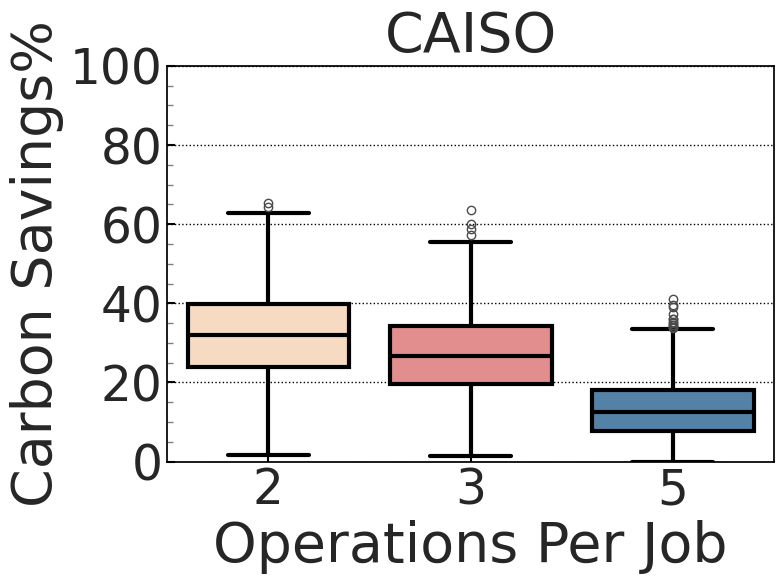

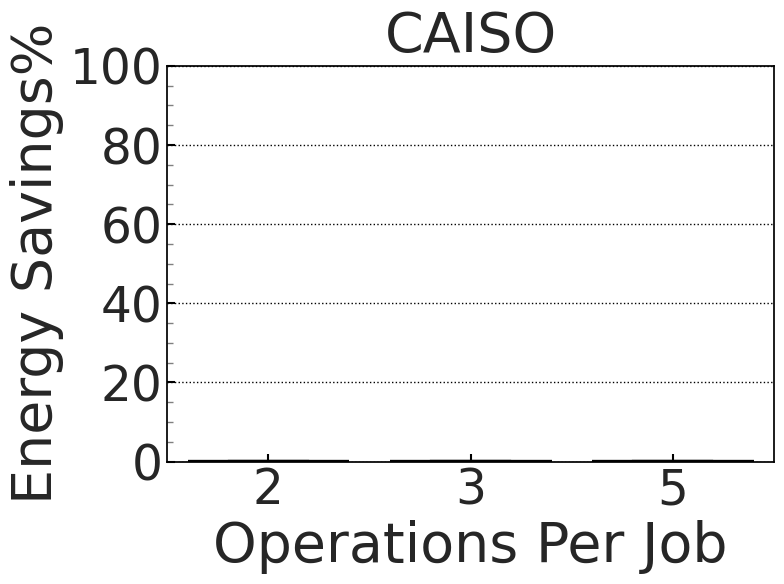

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import pandas as pd
###########
if location == "California":
    plot_title = "CAISO"
elif location == "AU-SA":
    plot_title = "AU-SA"
###########
save_fig = True
utilization_annotation = False
root_dir = f"./Effect of Parameters/Operations Per Job/{folder_type}/{location}"
########
df_box = df_logs[df_logs["IsCarbonAware"] == True].copy()
save_data = False
if save_data:
    save_path = f"{root_dir}/{num_jobs}J_{num_servers}S_BoxPlot_{plot_title}.csv"
    directory = os.path.dirname(save_path)
    os.makedirs(directory, exist_ok=True)
    df_plot.to_csv(save_path, index = False)
########
plot_types = ["Carbon Savings", "Energy Savings"]
column_names = ["CarbonSavings(%)", "EnergySavings(%)"]
for plot_index, plot_type in enumerate(plot_types):
    save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_BoxPlot_{plot_title}v2.png"
    # if mixed_objective:
    #     save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_WithTieBreaker_BoxPlot_{plot_title}.png"
    directory = os.path.dirname(save_file_path)
    os.makedirs(directory, exist_ok=True)
    
    # Seaborn & matplotlib styling
    sns.set(style="ticks", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    plt.rcParams['ytick.minor.visible'] = True
    
    # Filter for carbon-aware runs only
    unique_labels = sorted(df_box["OperationsPerJob"].unique())
    all_colors = ["lightseagreen", "khaki", "plum", "lightsalmon", "skyblue", "wheat", "orchid", "mistyrose", "lightcoral"]
    if folder_type in ["Heterogen", "Heterogen_Energy"]:
        inner_colors = ["lightseagreen", "khaki", "plum"]
    elif folder_type in ["Homogen", "Homogen_Energy"]:
        # inner_colors = ["lightcoral", "skyblue", "mistyrose"]
        # inner_colors = ["lightcoral", "wheat", "orchid"]
        inner_colors = ["peachpuff", "lightcoral", "steelblue"]
    palette = inner_colors[:len(unique_labels)]
    df_box["OperationsPerJob"] = df_box["OperationsPerJob"].astype(str)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    box = sns.boxplot(
        data=df_box,
        x="OperationsPerJob",
        y=column_names[plot_index],
        hue="OperationsPerJob",
        palette=palette,
        dodge=False,
        legend=False,
        ax = ax
    )
    
    
    # Forcefully update the patches
    for patch in ax.patches:
        patch.set_linewidth(3)
        patch.set_edgecolor("black")

    # Manually adjust all the lines for whiskers, caps, and medians
    for line in ax.lines:
        line.set_linewidth(3)
        line.set_color("black")
    
    # Axis labels
    ax.set_xlabel(r"Operations Per Job", fontsize=40)
    ax.set_ylabel(f"{plot_type}%", fontsize=40)

    # Axis ticks and limits
    # ax.set_ylim(-50, 100)
    ax.set_ylim(0, 100) #v2
    # ax.set_yticks(range(-50, 101, 25))
    ax.set_yticks(range(0, 101, 20)) #v2
    ax.tick_params(axis='x', labelsize=35, color='black')
    ax.tick_params(axis='y', labelsize=35, color='black')

    # Minor ticks
    ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')
    # Make major ticks point inward too
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.5)
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    # Ensure minor ticks are visible
    plt.minorticks_on()

    # Grid & borders
    ax.grid(axis='x', visible=False)
    ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
    ax.set_title(f"{plot_title}", fontsize=40, pad=10)
    plt.tight_layout()
    if save_fig:
        plt.savefig(save_file_path, dpi=300, bbox_inches='tight')
        pdf_save_path = save_file_path.replace(".png", ".pdf")
        plt.savefig(pdf_save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

# Plot4 - Effect of Location

In [118]:
import pandas as pd
import glob
import os
list_locations = ["Texas", "Germany", "California", "AU-SA", "CA-ON"]
translated_list = ["TEX", "GER", "CAISO", "AU-SA", "CA-ON"]
# location = "AU-SA"
location = "California"
#############
folder_type = "Homogen"
# folder_type = "Heterogen"
# folder_type = "Heterogen_Energy"
############
# root_dir = f"../Logs/GeneralExp"
root_dir = f"../Logs/GeneralExpv2/{folder_type}/{location}"
num_jobs = 10
num_servers = 5
num_operations = 3
list_dfs = []
for i, location in enumerate(list_locations):
    # reading the df for a specific number of servers
    root_dir = f"../Logs/GeneralExpv2/{folder_type}/{location}"
    pattern = f"{num_jobs}J_{num_servers}S_{num_operations}O_MeanOp=7_v*.csv"
    csv_files = glob.glob(f"{root_dir}/{pattern}")
    df_logs = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
    df_logs = df_logs[df_logs["SlackCoeff"] == 1]
    # Calculating the carbon and energy savings
    # First, get baseline carbon consumption per instance where IsCarbonAware is False
    baseline = df_logs[df_logs["IsCarbonAware"] == False][["Instance", "CarbonConsumption(g)", "EnergyConsumption(kWh)"]]
    baseline = baseline.rename(columns={"CarbonConsumption(g)": "BaselineCarbon", "EnergyConsumption(kWh)": "BaselineEnergy"})
    # Merge it back to original df to align baseline carbon for each instance
    df_logs = df_logs.merge(baseline, on="Instance", how="left")
    # Calculate savings
    df_logs["CarbonSavings(%)"] = ((df_logs["BaselineCarbon"] - df_logs["CarbonConsumption(g)"]) / df_logs["BaselineCarbon"]) * 100
    df_logs["EnergySavings(%)"] = ((df_logs["BaselineEnergy"] - df_logs["EnergyConsumption(kWh)"]) / df_logs["BaselineEnergy"]) * 100
    df_logs.drop(columns=["BaselineCarbon", "BaselineEnergy"], inplace=True)
    # Optional: round to 2 decimal places
    df_logs["CarbonSavings(%)"] = df_logs["CarbonSavings(%)"].round(2)
    df_logs["EnergySavings(%)"] = df_logs["EnergySavings(%)"].round(2)
    df_logs["Location"] = translated_list[i]
    # adding to list of dfs
    list_dfs.append(df_logs)
    print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_logs.shape}")
df_union = pd.concat(list_dfs, ignore_index=True)
df_logs = df_union[["Instance", "Location", "IsCarbonAware", "MaxMakeSpan", "MinMakeSpan", "SlackCoeff", "Makespan", "CarbonConsumption(g)", "EnergyConsumption(kWh)", "CarbonSavings(%)", "EnergySavings(%)"]]
# df_union = df_union[df_union["SlackCoeff"] == 1]

✅ Loaded and merged 8 files. Final shape: (2160, 26)
✅ Loaded and merged 8 files. Final shape: (2160, 26)
✅ Loaded and merged 8 files. Final shape: (2160, 26)
✅ Loaded and merged 8 files. Final shape: (2160, 26)
✅ Loaded and merged 8 files. Final shape: (2160, 26)


In [119]:
len(df_logs)

10800

In [120]:
df_logs

,Instance,Location,IsCarbonAware,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),EnergyConsumption(kWh),CarbonSavings(%),EnergySavings(%)
0,0,TEX,False,672,111,1.0,111,15374.00,37.50,0.00,0.0
1,0,TEX,True,111,111,1.0,111,14750.25,37.50,4.06,0.0
2,1,TEX,False,672,142,1.0,142,24635.25,58.00,0.00,0.0
3,1,TEX,True,142,142,1.0,142,23039.50,58.00,6.48,0.0
4,2,TEX,False,672,123,1.0,123,27905.75,60.50,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...
10795,1077,CA-ON,True,109,109,1.0,109,5818.50,57.25,8.13,0.0
10796,1078,CA-ON,False,672,87,1.0,87,4623.75,40.75,0.00,0.0
10797,1078,CA-ON,True,87,87,1.0,87,4308.25,40.75,6.82,0.0
10798,1079,CA-ON,False,672,95,1.0,95,6144.50,54.00,0.00,0.0


In [121]:
import pandas as pd

# Filter only carbon-aware rows
df_filtered = df_logs[df_logs["IsCarbonAware"] == True].copy()
df_carbon_savings = df_filtered.groupby("Location")["CarbonSavings(%)"].mean().reset_index()
df_energy_savings = df_filtered.groupby("Location")["EnergySavings(%)"].mean().reset_index()
df_plot = pd.merge(df_carbon_savings, df_energy_savings, on="Location")
# df_plot['UtilizationRatio'] = df_plot['SlackCoeff'].map(util_final_ratio)

In [122]:
df_plot

,Location,CarbonSavings(%),EnergySavings(%)
0,AU-SA,31.116722,0.0
1,CA-ON,11.763611,0.0
2,CAISO,26.956583,0.0
3,GER,9.575630,0.0
4,TEX,9.483093,0.0


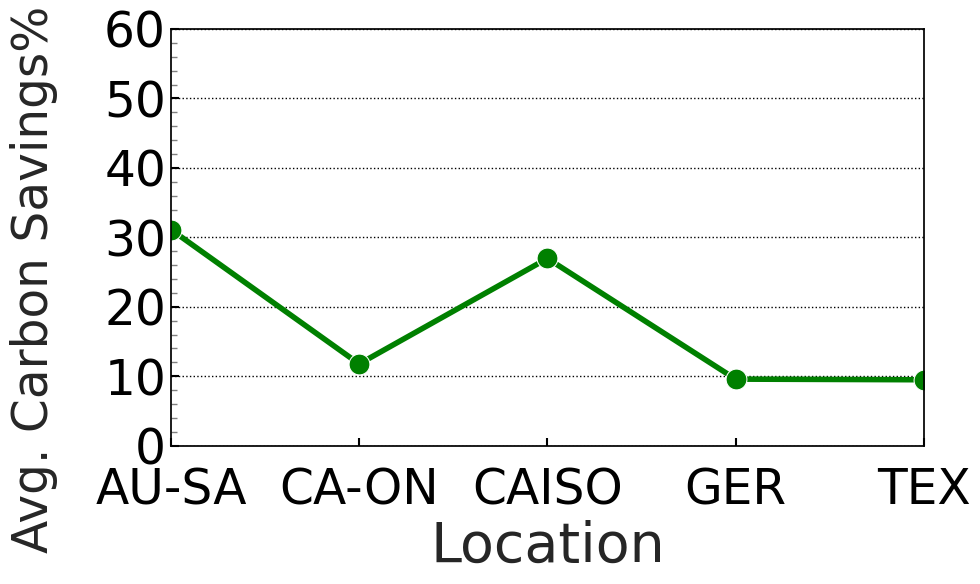

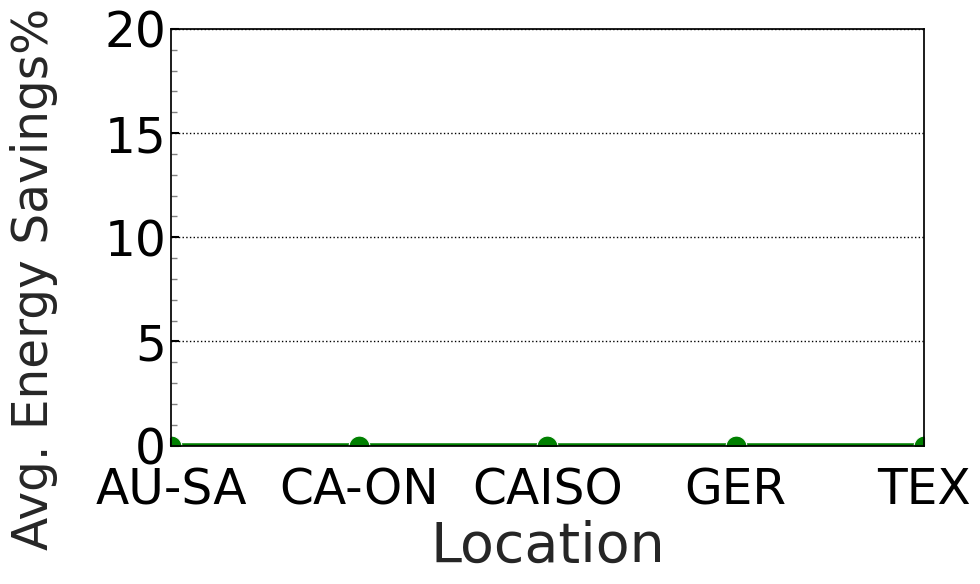

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import pandas as pd

###########
save_fig = True
utilization_annotation = False
root_dir = f"./Effect of Parameters/Location/{folder_type}"
########
save_data = True
if save_data:
    save_path = f"{root_dir}/{num_jobs}J_{num_servers}S_{num_operations}O_LinePlot.csv"
    # if mixed_objective:
    #     save_file_path = f"{root_dir}/{num_jobs}J_{num_operations}O_WithTieBreaker_LinePlot_{plot_title}.csv"
    directory = os.path.dirname(save_path)
    os.makedirs(directory, exist_ok=True)
    df_plot.to_csv(save_path, index = False)
###########
plot_types = ["Carbon Savings", "Energy Savings"]
column_names = ["CarbonSavings(%)", "EnergySavings(%)"]
for plot_index, plot_type in enumerate(plot_types):
    save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_LinePlot.png"
    directory = os.path.dirname(save_file_path)
    os.makedirs(directory, exist_ok=True)

    # Seaborn & matplotlib styling
    # sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    sns.set(style="ticks", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    # Reset rcParams that might affect ticks
    plt.rcParams['ytick.minor.visible'] = True
    # Ensure 'x_label' is treated as string (categorical)
    df_plot["Location"] = df_plot["Location"].astype(str)
    
    line_color = "green"
    if folder_type in ["Heterogen_Energy"]:
        line_color = "red"

    plt.figure(figsize=(10, 6))
    ax = sns.lineplot(
        data=df_plot,
        x="Location",
        y=column_names[plot_index],
        marker="o",
        markersize=15,
        linewidth=4,
        color=line_color
    )

    # Labels
    # ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
    ax.set_xlabel(r"Location", fontsize=40)
    
    ax.set_ylabel(f"Avg. {plot_type}%", fontsize=35)
    ax.yaxis.set_label_coords(-0.15, 0.40)  # Move it 5% lower on the y-axis

    # Axis limits and tick font sizes
    if plot_type == "Carbon Savings":
        ax.set_ylim(0, 60)
        ax.set_yticks(range(0, 61, 10))
    else:
        ax.set_ylim(0, 20)
        ax.set_yticks(range(-0, 21, 5))
    ax.set_xlim(0, len(list(df_plot["Location"]))-1)
    ax.tick_params(axis='x', labelsize=35, color='black', pad=15)
    ax.tick_params(axis='y', labelsize=35, color='black')
    
    # Minor ticks
    ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')
    # Make major ticks point inward too
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.5)
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    # Ensure minor ticks are visible
    plt.minorticks_on()

    # Grid settings
    ax.grid(axis='x', visible=False)  # No x-grid
    ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
    # ax.grid(axis='y', which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.7)

    # Black border and ticks
    ax.tick_params(axis='both', color='black', labelcolor='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        
    # ax.set_title(f"{plot_title}", fontsize=40, pad=10)

    # Annotate each point with UtilizationRatio
    if utilization_annotation:
        if plot_type == "Carbon Savings":
            for index, row in df_plot.iterrows():
                utilization_ratio = row['UtilizationRatio']
                x_pos = row['Location']
                y_pos = row[column_names[plot_index]]
                
                # If it's the first point, adjust it slightly to the right
                if index == 0:
                    ax.text(float(x_pos) - 0.9, y_pos + 3, f"{utilization_ratio:.2f}%", 
                            color='black', fontsize=12, ha='center', va='bottom')
                else:
                    ax.text(x_pos, y_pos + 1.5, f"{utilization_ratio:.2f}%", 
                            color='black', fontsize=12, ha='center', va='bottom')

    plt.tight_layout()
    if save_fig:
        plt.savefig(save_file_path, dpi=300, bbox_inches='tight')
        pdf_save_path = save_file_path.replace(".png", ".pdf")
        plt.savefig(pdf_save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

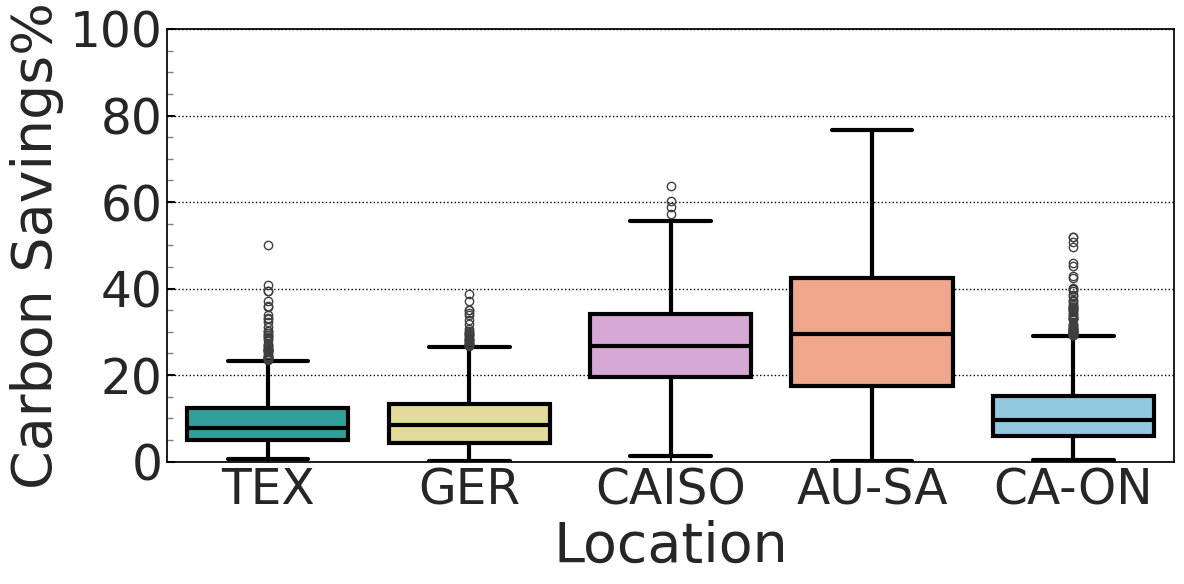

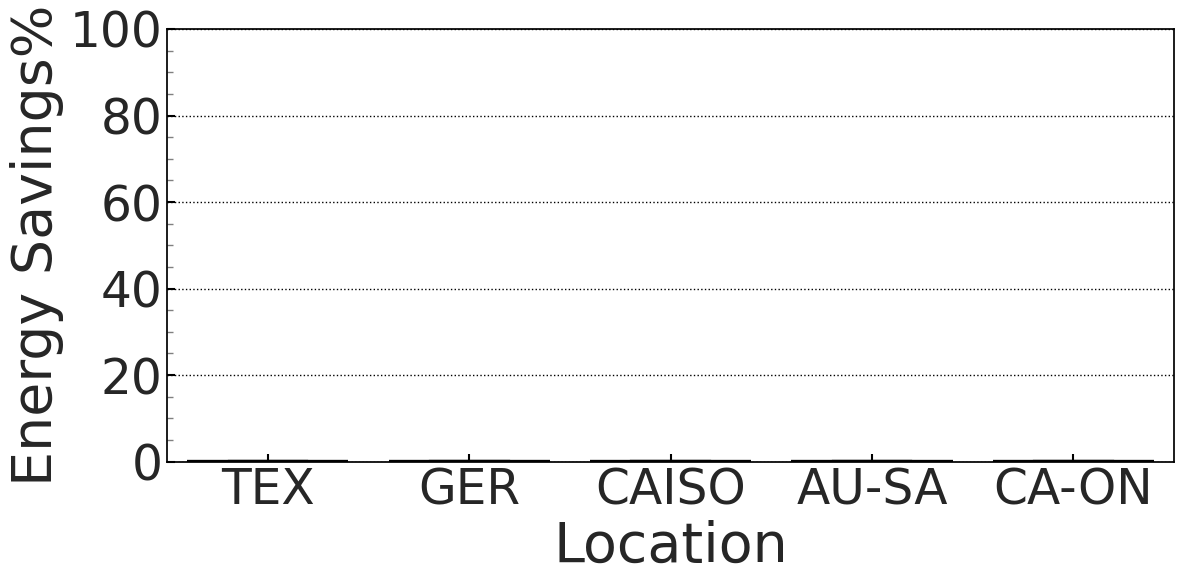

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import pandas as pd
###########e = "AU-SA"
###########
save_fig = True
utilization_annotation = False
root_dir = f"./Effect of Parameters/Location/{folder_type}"
########
df_box = df_logs[df_logs["IsCarbonAware"] == True].copy()
save_data = False
if save_data:
    save_path = f"{root_dir}/{num_jobs}J_{num_servers}S_{num_operations}O_BoxPlot.csv"
    directory = os.path.dirname(save_path)
    os.makedirs(directory, exist_ok=True)
    df_plot.to_csv(save_path, index = False)
########
plot_types = ["Carbon Savings", "Energy Savings"]
column_names = ["CarbonSavings(%)", "EnergySavings(%)"]
for plot_index, plot_type in enumerate(plot_types):
    save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_BoxPlotv2.png"
    # if mixed_objective:
    #     save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_WithTieBreaker_BoxPlot_{plot_title}.png"
    directory = os.path.dirname(save_file_path)
    os.makedirs(directory, exist_ok=True)
    
    # Seaborn & matplotlib styling
    sns.set(style="ticks", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    plt.rcParams['ytick.minor.visible'] = True
    
    # Filter for carbon-aware runs only
    unique_labels = sorted(df_box["Location"].unique())
    all_colors = ["lightseagreen", "khaki", "plum", "lightsalmon", "skyblue", "wheat", "orchid", "mistyrose", "lightcoral"]
    if folder_type in ["Heterogen", "Heterogen_Energy"]:
        inner_colors = ["lightseagreen", "khaki", "plum"]
    elif folder_type in ["Homogen", "Homogen_Energy"]:
        # inner_colors = ["lightcoral", "skyblue", "mistyrose"]
        # inner_colors = ["lightcoral", "wheat", "orchid"]
        # inner_colors = ["peachpuff", "lightcoral", "steelblue"]
        inner_colors = ["lightseagreen", "khaki", "plum", "lightsalmon", "skyblue", "wheat", "orchid", "mistyrose", "lightcoral"]
    palette = inner_colors[:len(unique_labels)]
    df_box["Location"] = df_box["Location"].astype(str)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    box = sns.boxplot(
        data=df_box,
        x="Location",
        y=column_names[plot_index],
        hue="Location",
        palette=palette,
        dodge=False,
        legend=False,
        ax = ax
    )
    
    
    # Forcefully update the patches
    for patch in ax.patches:
        patch.set_linewidth(3)
        patch.set_edgecolor("black")

    # Manually adjust all the lines for whiskers, caps, and medians
    for line in ax.lines:
        line.set_linewidth(3)
        line.set_color("black")
    
    # Axis labels
    ax.set_xlabel(r"Location", fontsize=40)
    ax.set_ylabel(f"{plot_type}%", fontsize=40)

    # Axis ticks and limits
    # ax.set_ylim(-50, 100)
    ax.set_ylim(0, 100) #v2
    # ax.set_yticks(range(-50, 101, 25))
    ax.set_yticks(range(0, 101, 20)) #v2
    ax.tick_params(axis='x', labelsize=35, color='black')
    ax.tick_params(axis='y', labelsize=35, color='black')

    # Minor ticks
    ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')
    # Make major ticks point inward too
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.5)
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    # Ensure minor ticks are visible
    plt.minorticks_on()

    # Grid & borders
    ax.grid(axis='x', visible=False)
    ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
    # ax.set_title(f"{plot_title}", fontsize=40, pad=10)
    plt.tight_layout()
    if save_fig:
        plt.savefig(save_file_path, dpi=300, bbox_inches='tight')
        pdf_save_path = save_file_path.replace(".png", ".pdf")
        plt.savefig(pdf_save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

# Plot5 - Server activity plots

In [91]:
import pandas as pd
import glob
import os
# location = "AU-SA"
location = "California"
#############
folder_type = "Homogen"
# folder_type = "Heterogen"
# folder_type = "Heterogen_Energy"
############
# root_dir = f"../Logs/GeneralExp"
root_dir = f"../Logs/GeneralExpv2/{folder_type}/{location}"
num_jobs = 10
num_servers = 5
#############

# Define the pattern
pattern = f"{num_jobs}J_{num_servers}S_3O_MeanOp=7_v*.csv"

# Get list of matching files
csv_files = glob.glob(f"{root_dir}/{pattern}")

# Read and concatenate all files
df_union = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_union.shape}")

✅ Loaded and merged 8 files. Final shape: (4320, 23)


In [92]:
import ast
df_server_activity = df_union[(df_union["Instance"] == 0) & (df_union["SlackCoeff"] == 1)]
df_server_activity = df_server_activity.drop(columns=['ServerNumber', 'ServerPower'])
server_columns = [col for col in df_server_activity.columns if col.startswith('Server')]
for col in server_columns:
    df_server_activity[col] = df_server_activity[col].apply(ast.literal_eval)

In [93]:
df_server_activity

,ElapsedTime,Datetime,Instance,IsCarbonAware,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),EnergyConsumption(kWh),...,OperationsPerJob,EpochDuration(min),SolverTimer(min),JobIndex,JobArrivalEpoch,Server0,Server1,Server2,Server3,Server4
0,0:00:00,2024-01-01,0,False,672,111,1.0,111,12887.25,37.5,...,3,15,1,"['654', '114', '25', '759', '281', '250', '228...","[3, 13, 14, 17, 28, 31, 35, 81, 94, 94]","[[654, 0, 3, 10], [114, 0, 13, 29], [114, 1, 5...","[[654, 2, 21, 24], [25, 2, 49, 55], [759, 0, 1...","[[25, 1, 32, 35], [759, 1, 20, 22], [228, 1, 4...","[[142, 0, 81, 83], [142, 1, 83, 84]]","[[654, 1, 10, 21], [754, 1, 95, 104]]"
1,0:01:06,2024-01-01,0,True,111,111,1.0,111,7994.25,37.5,...,3,15,1,"['654', '114', '25', '759', '281', '250', '228...","[3, 13, 14, 17, 28, 31, 35, 81, 94, 94]","[[114, 0, 75, 91], [114, 1, 91, 92], [114, 2, ...","[[759, 0, 72, 75], [759, 1, 83, 85], [250, 0, ...","[[25, 1, 80, 83], [250, 1, 79, 80], [228, 0, 6...","[[654, 0, 72, 79], [654, 2, 93, 96], [25, 2, 8...","[[654, 1, 79, 90], [759, 2, 90, 95], [281, 0, ..."


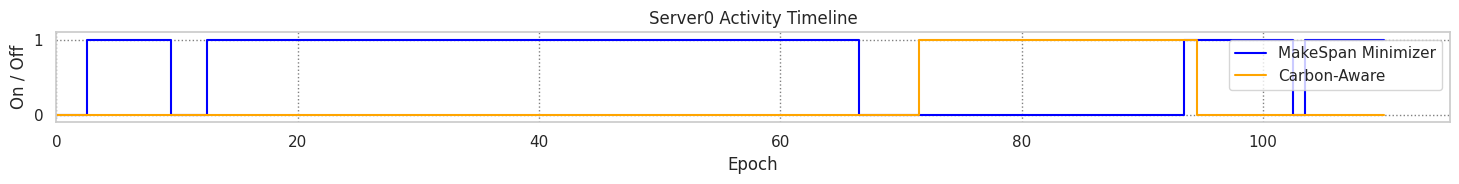

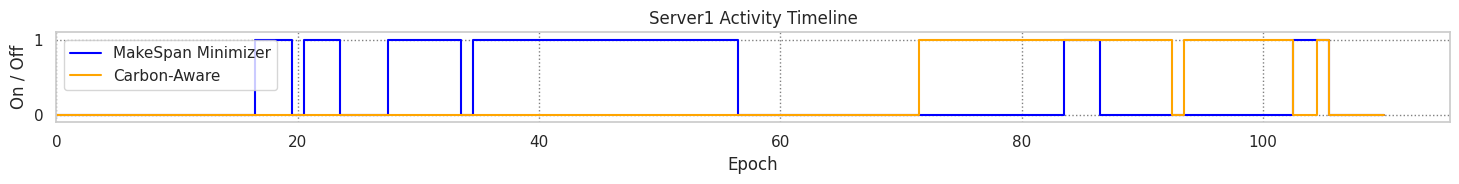

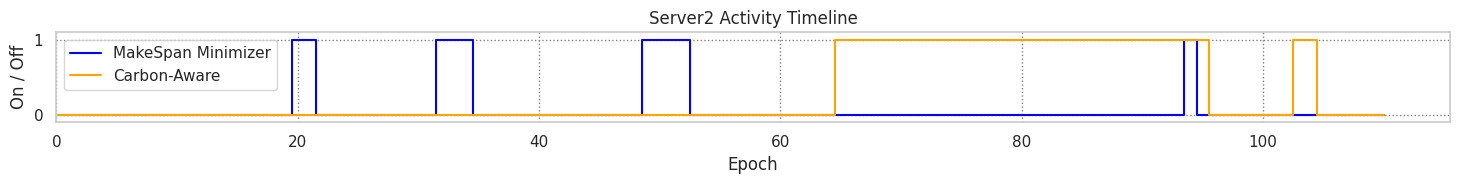

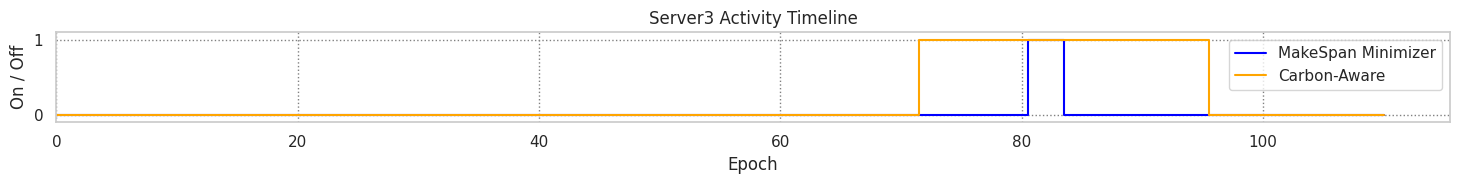

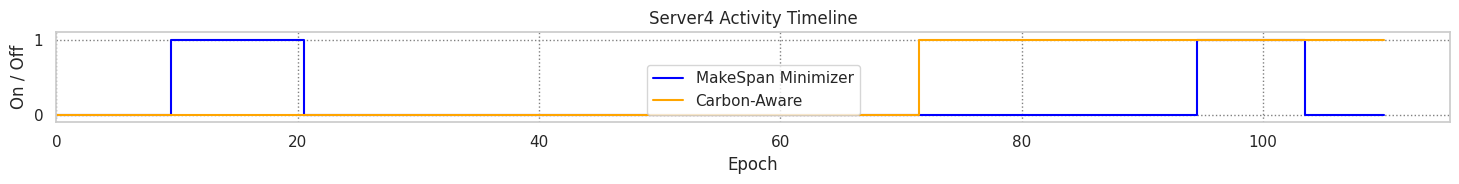

In [94]:
import matplotlib.pyplot as plt
import numpy as np

save_fig = True
# Get the list of servers from the dataframe
server_columns = [col for col in df_server_activity.columns if col.startswith("Server")]
colors = ['blue', 'orange']  # Colors for different rows
labels = ["MakeSpan Minimizer", "Carbon-Aware"]
# Iterate over each server
for server_id in server_columns:
    plt.figure(figsize=(15, 2))
    
    # Iterate over each row (max 2 rows for this plot)
    for index, (row, color) in enumerate(zip(df_server_activity.iterrows(), colors)):
        row_data = row[1]
        min_makespan = row_data["MinMakeSpan"]
        server_status = row_data[server_id]
        
        # Initialize the time series with zeros
        timeline = np.zeros(min_makespan)
        
        # If the data is a string, we eval it
        if isinstance(server_status, str):
            server_status = eval(server_status)

        # Set the periods where the server is active to 1
        for [job_id, operation_id, start, end] in server_status:
            timeline[start:end] = 1
        
        # Plot
        plt.step(range(min_makespan), timeline, where='mid', color=color, label=labels[index])
    
    plt.ylim(-0.1, 1.1)
    plt.xlim(left=0)
    plt.title(f"{server_id} Activity Timeline")
    plt.ylabel("On / Off")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(True, linestyle=':', color='gray')
    plt.tight_layout()
    if save_fig:
        plt.savefig(f"./ServersActivity/{folder_type}/{location}/Server{server_id}.png", dpi=300, bbox_inches='tight')
    plt.show()

# Calculating Average Completion Time

In [77]:
import pandas as pd
import glob
import os
# location = "AU-SA"
location = "California"
#############
folder_type = "Homogen"
# folder_type = "Heterogen"
# folder_type = "Heterogen_Energy"
############
mixed_objective = False # for energy-aware optimization that had a tie braker of carbon term
############
# root_dir = f"../Logs/GeneralExp"
root_dir = f"../Logs/GeneralExpv2/{folder_type}/{location}"
num_jobs = 10
num_servers = 5
num_operations = 3
#############

# Define the pattern
pattern = f"{num_jobs}J_{num_servers}S_{num_operations}O_MeanOp=7_v*.csv"
if mixed_objective:
    pattern = f"{num_jobs}J_{num_servers}S_{num_operations}O_MeanOp=7_MixedObjective_v*.csv"

# Get list of matching files
csv_files = glob.glob(f"{root_dir}/{pattern}")

# Read and concatenate all files
df_union = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
df_union = df_union[df_union["SlackCoeff"] == 1]

print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_union.shape}")

✅ Loaded and merged 8 files. Final shape: (2160, 23)


In [78]:
import ast

def calculate_completion_times(row):
    # Extract the Job Arrival Epochs
    job_arrival_epochs = ast.literal_eval(row["JobArrivalEpoch"])
    
    # Create a dictionary to track the maximum end epoch for each job
    job_end_epochs = {int(job_id): 0 for job_id in ast.literal_eval(row["JobIndex"])}
    # print(job_end_epochs)

    # Loop through each server and update the end epoch for each job
    for server_id in range(num_servers):
        # server_col = f"Server{server_id}"
        server_col = ast.literal_eval(row[f"Server{server_id}"])
        # print(f"Server {server_id} - {server_col}")
        if server_col:  # Check if there are any jobs on this server
            for job_id, _, _, end_epoch in server_col:
                if job_id in job_end_epochs:
                    job_end_epochs[job_id] = max(job_end_epochs[job_id], end_epoch)
    # print(job_end_epochs)

    # Calculate the completion time for each job
    job_completion_times = [
        max(0, job_end_epochs[int(job_id)] - job_arrival_epochs[idx]) 
        for idx, job_id in enumerate(ast.literal_eval(row["JobIndex"]))
    ]
    # print(job_completion_times)

    return job_completion_times

# Apply the function to your dataframe
# df_union["JobCompletionTimes"] = df_union.apply(calculate_completion_times, axis=1)
df_union.loc[:, "JobCompletionTimes"] = df_union.apply(calculate_completion_times, axis=1)

In [79]:
df_union = df_logs = df_union[["Instance", "IsCarbonAware", "MaxMakeSpan", "MinMakeSpan", "SlackCoeff", "Makespan", "CarbonConsumption(g)", "EnergyConsumption(kWh)", "JobCompletionTimes"]]

In [80]:
df_union

,Instance,IsCarbonAware,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),EnergyConsumption(kWh),JobCompletionTimes
0,0,False,672,111,1.0,111,12887.25,37.50,"[21, 41, 41, 33, 29, 14, 32, 6, 17, 12]"
1,0,True,111,111,1.0,111,7994.25,37.50,"[93, 81, 76, 78, 53, 62, 61, 12, 17, 12]"
4,1,False,672,142,1.0,142,18906.25,58.00,"[50, 45, 73, 41, 44, 20, 16, 25, 37, 48]"
5,1,True,142,142,1.0,142,14490.00,58.00,"[96, 96, 85, 89, 77, 40, 26, 28, 18, 48]"
8,2,False,672,123,1.0,123,17032.75,60.50,"[14, 23, 19, 18, 49, 39, 46, 37, 15, 31]"
...,...,...,...,...,...,...,...,...,...
4309,1077,True,109,109,1.0,109,9581.50,57.25,"[83, 93, 79, 68, 54, 41, 26, 26, 14, 18]"
4312,1078,False,672,87,1.0,87,8119.00,40.75,"[12, 27, 14, 28, 40, 34, 46, 25, 31, 27]"
4313,1078,True,87,87,1.0,87,6712.75,40.75,"[80, 75, 69, 49, 49, 34, 46, 38, 30, 28]"
4316,1079,False,672,95,1.0,95,10336.25,54.00,"[42, 56, 44, 32, 63, 19, 28, 15, 19, 19]"


In [81]:
df_makespan_minimizer = df_union[df_union["IsCarbonAware"] == False]
df_carbon_minimizer = df_union[df_union["IsCarbonAware"] == True]

In [82]:
# list_msmin_comp_time = list(df_makespan_minimizer["JobCompletionTimes"])
list_msmin_comp_time = [item for sublist in list(df_makespan_minimizer["JobCompletionTimes"]) for item in sublist]
list_carbon_comp_time = [item for sublist in list(df_carbon_minimizer["JobCompletionTimes"]) for item in sublist]

In [83]:
len(list_msmin_comp_time), len(list_carbon_comp_time)

(10800, 10800)

In [84]:
import numpy as np
np.average(list_msmin_comp_time), np.average(list_carbon_comp_time)

(np.float64(29.02962962962963), np.float64(45.86398148148148))